[*********************100%***********************]  3 of 3 completed


 Close prices downloaded:
Ticker           AAPL       GOOG        MSFT
Date                                        
2020-01-02  72.716057  68.046196  153.323273
2020-01-03  72.009117  67.712280  151.414124
2020-01-06  72.582909  69.381874  151.805496
2020-01-07  72.241547  69.338585  150.421356
2020-01-08  73.403641  69.884995  152.817368


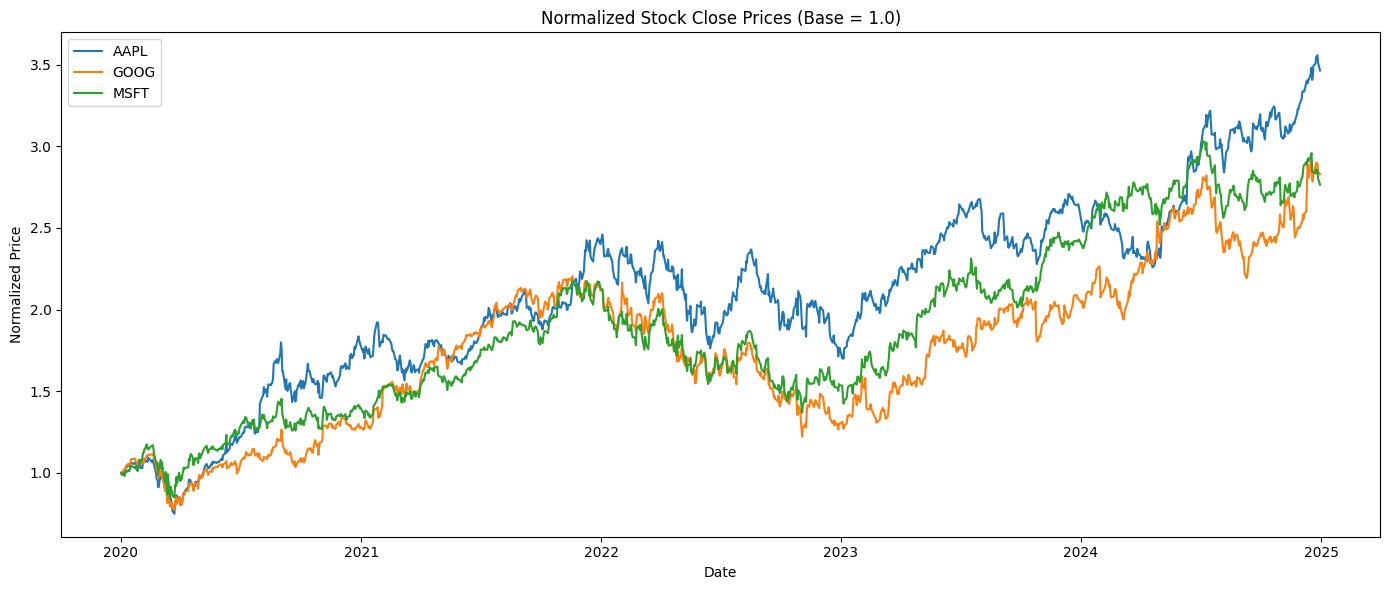

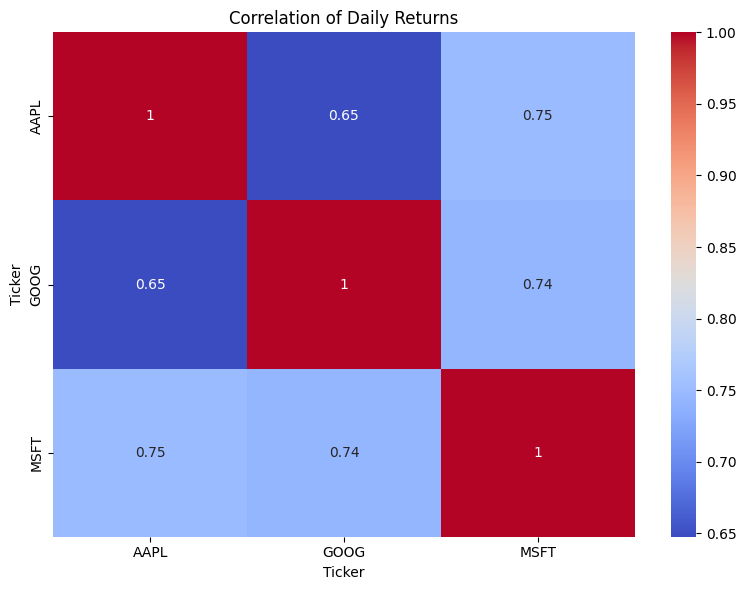

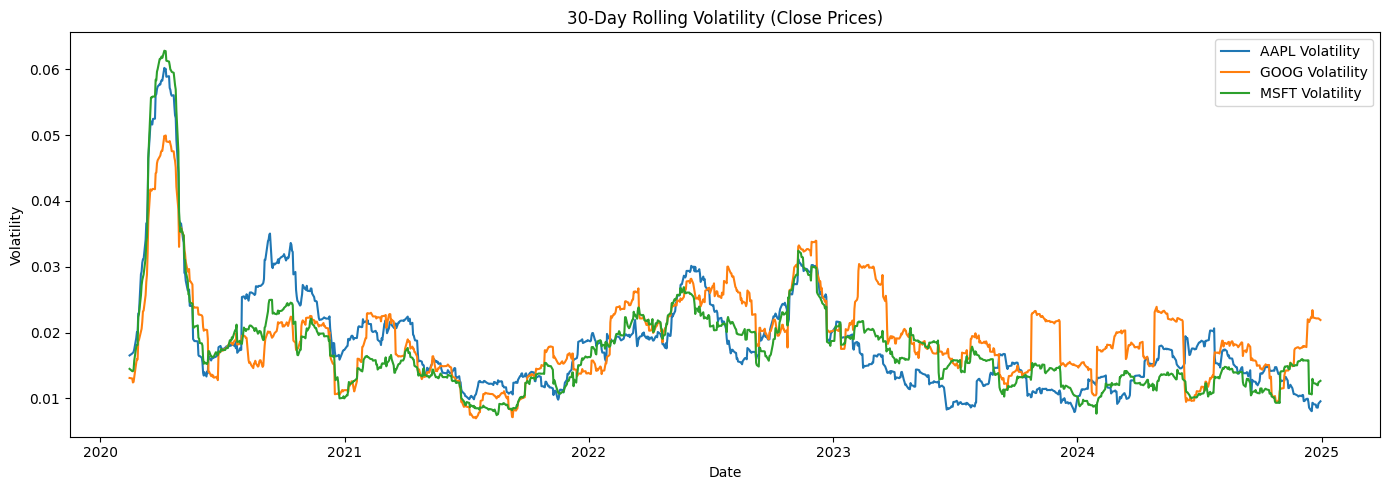


 Summary Statistics for Daily Returns (Close):
Ticker         AAPL         GOOG         MSFT
count   1256.000000  1256.000000  1256.000000
mean       0.001189     0.001036     0.000995
std        0.019962     0.020406     0.019217
min       -0.128647    -0.111008    -0.147390
25%       -0.008426    -0.009525    -0.008248
50%        0.001210     0.002129     0.001113
75%        0.012017     0.011248     0.010947
max        0.119808     0.099652     0.142169


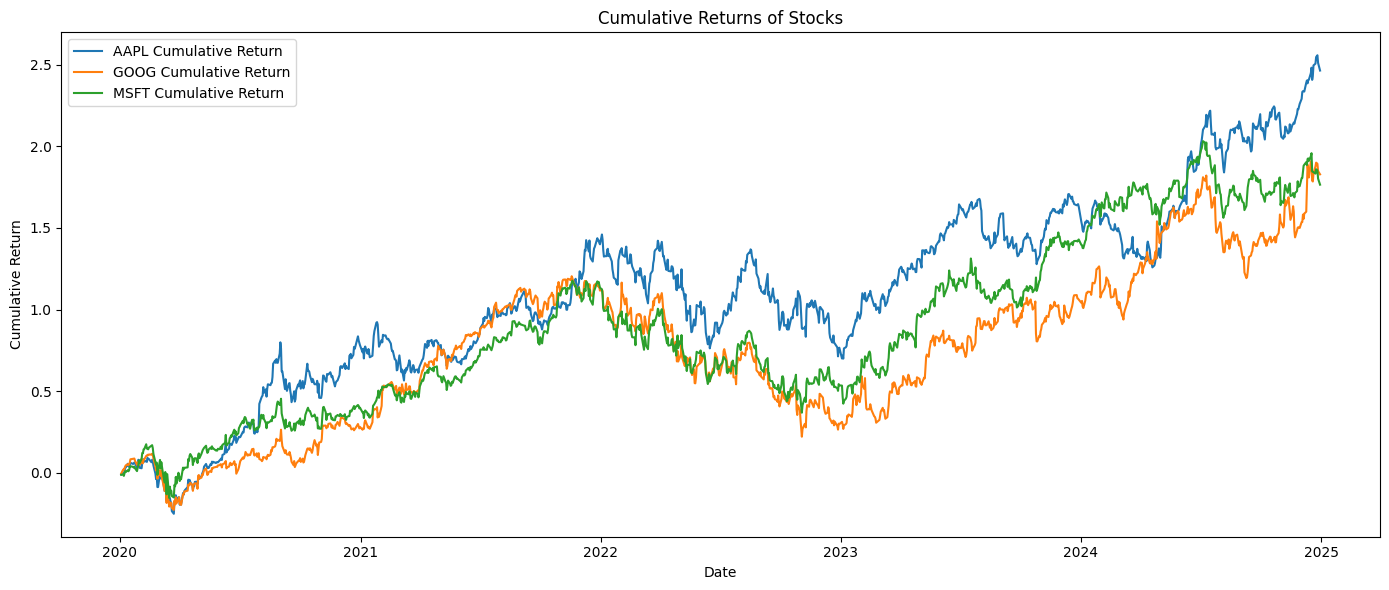

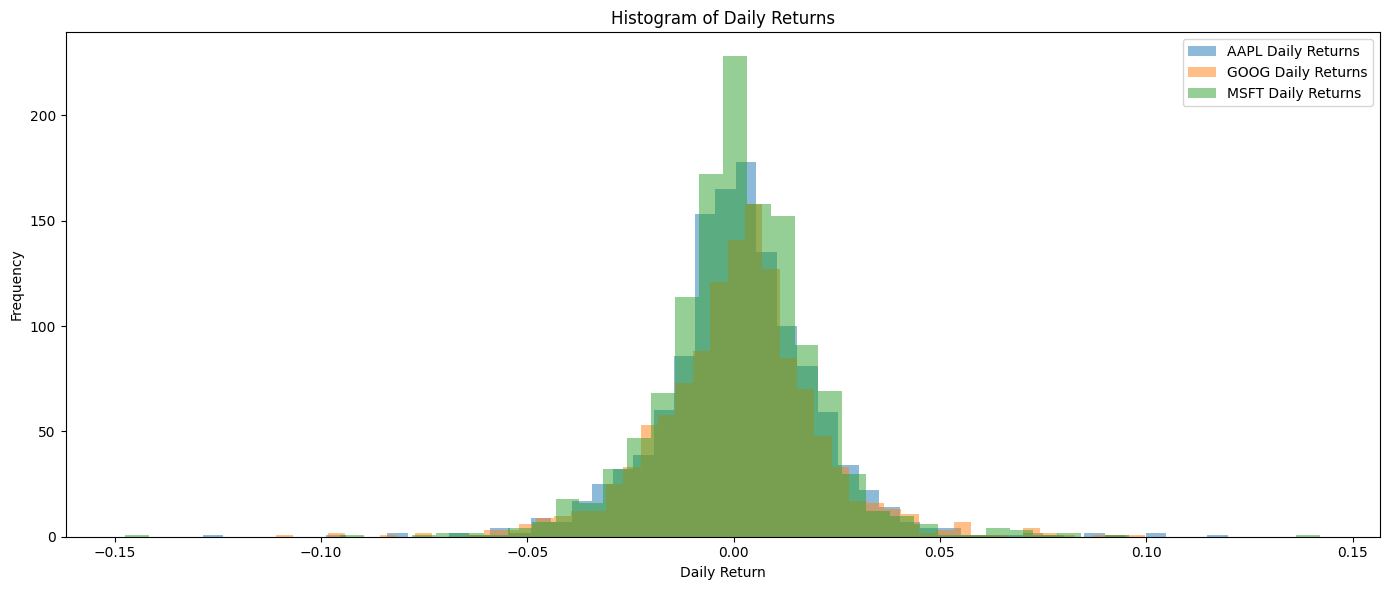

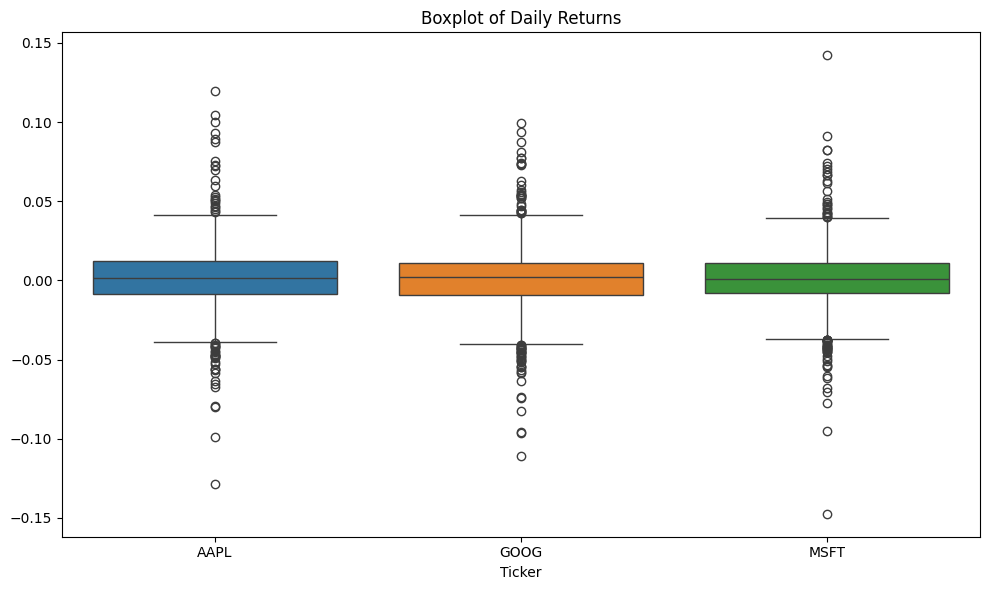

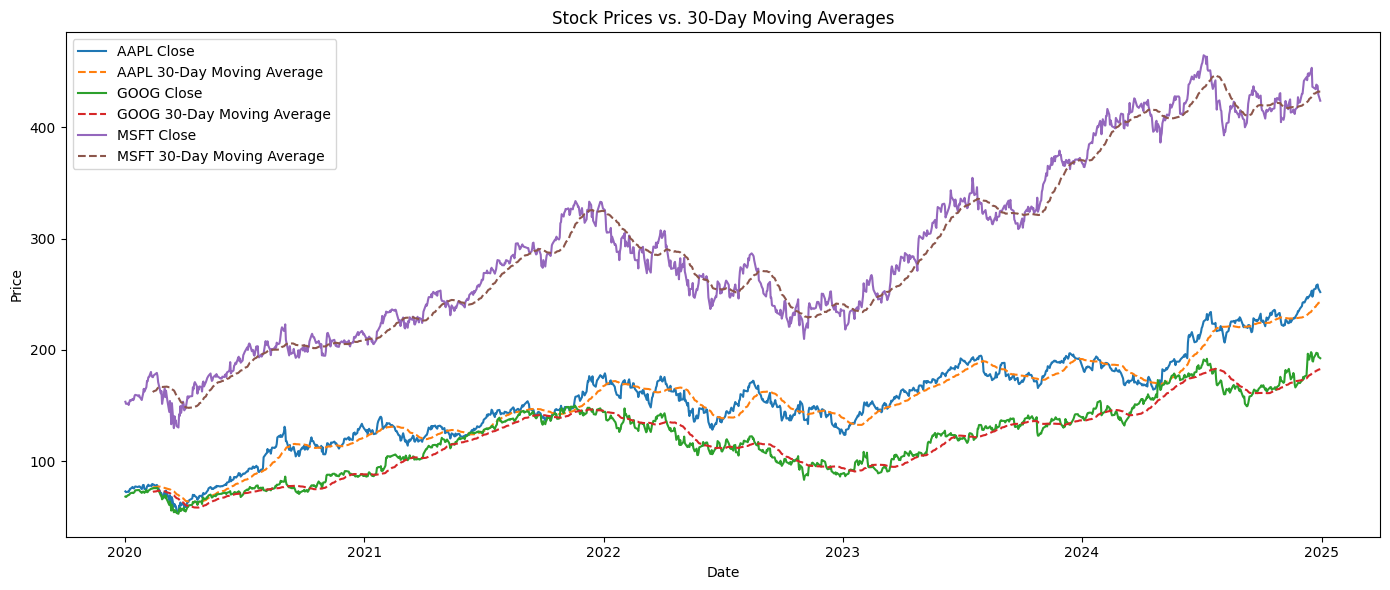

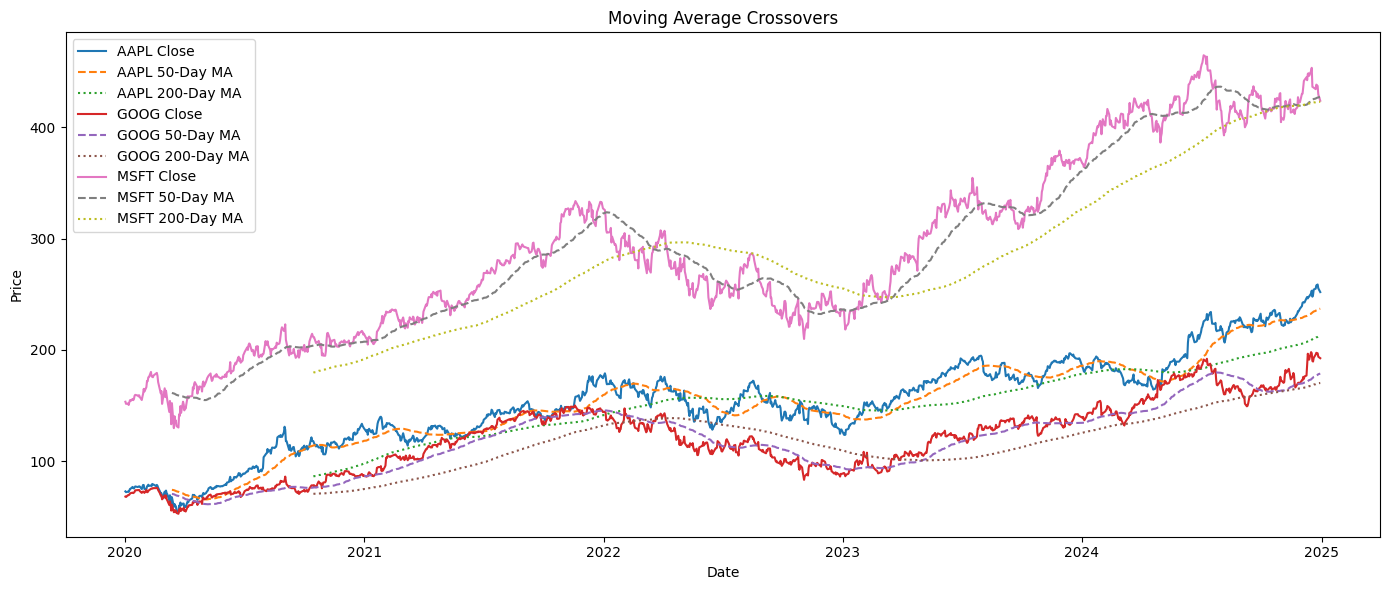

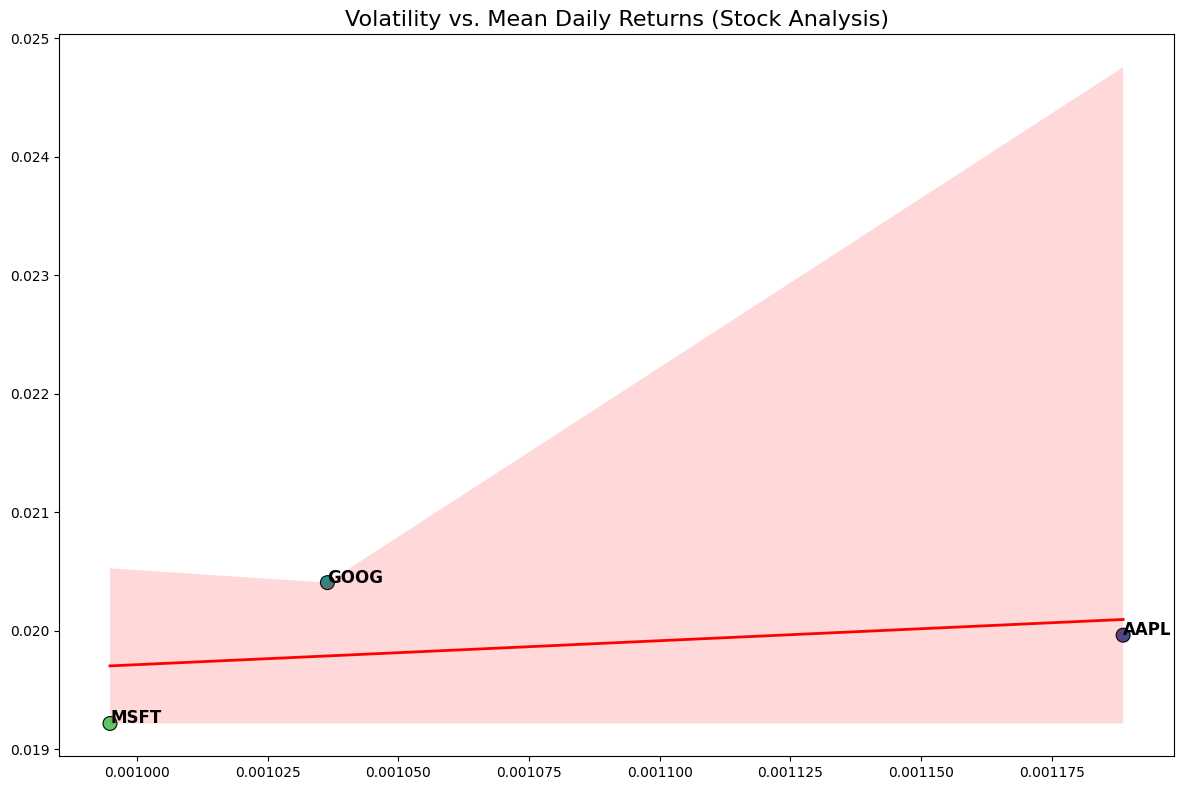

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Define tickers and time range
tickers = ['AAPL', 'MSFT', 'GOOG']  # Apple, Microsoft, Google
start_date = '2020-01-01'
end_date = '2024-12-31'
#Step 1: Download full stock data
data = yf.download(tickers, start=start_date, end=end_date)
# Step 2: Extract only 'Close' prices
if isinstance(data.columns, pd.MultiIndex):
    close_data = data['Close']
else:
    close_data = data[['Close']]  # fallback for single ticker
# Safety check
if close_data.empty:
    print(" No data downloaded. Check your ticker symbols or internet connection.")
else:
    print(" Close prices downloaded:")
    print(close_data.head())
# Step 3: Normalize prices for comparison
normalized_data = close_data / close_data.iloc[0]
plt.figure(figsize=(14, 6))
for ticker in normalized_data.columns:
    plt.plot(normalized_data[ticker], label=ticker)
plt.title('Normalized Stock Close Prices (Base = 1.0)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.tight_layout()
plt.show()
# Step 4: Calculate daily returns
daily_returns = close_data.pct_change()
# Step 5: Correlation heatmap of returns
plt.figure(figsize=(8, 6))
sns.heatmap(daily_returns.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Daily Returns')
plt.tight_layout()
plt.show()
#  Step 6: Rolling 30-day volatility
rolling_vol = daily_returns.rolling(window=30).std()
plt.figure(figsize=(14, 5))
for ticker in rolling_vol.columns:
    plt.plot(rolling_vol[ticker], label=f'{ticker} Volatility')
plt.title('30-Day Rolling Volatility (Close Prices)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()
# Step 7: Summary statistics for daily returns
print("\n Summary Statistics for Daily Returns (Close):")
print(daily_returns.describe())
# Step 8: Cumulative Returns Plot
cumulative_returns = (1 + daily_returns).cumprod() - 1
plt.figure(figsize=(14, 6))
for ticker in cumulative_returns.columns:
    plt.plot(cumulative_returns[ticker], label=f'{ticker} Cumulative Return')
plt.title('Cumulative Returns of Stocks')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()
plt.show()
# Step 9: Histogram of Daily Returns
plt.figure(figsize=(14, 6))
for ticker in daily_returns.columns:
    plt.hist(daily_returns[ticker].dropna(), bins=50, alpha=0.5, label=f'{ticker} Daily Returns')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
# Step 10: Boxplot for Daily Returns
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_returns)
plt.title('Boxplot of Daily Returns')
plt.tight_layout()
plt.show()
# Step 11: Rolling 30-Day Moving Average of Closing Prices
moving_avg = close_data.rolling(window=30).mean()
plt.figure(figsize=(14, 6))
for ticker in moving_avg.columns:
    plt.plot(close_data[ticker], label=f'{ticker} Close')
    plt.plot(moving_avg[ticker], label=f'{ticker} 30-Day Moving Average', linestyle='--')
plt.title('Stock Prices vs. 30-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()
# Step 12: Moving Average Crossovers (Short vs. Long-term)
short_window = 50
long_window = 200
short_ma = close_data.rolling(window=short_window).mean()
long_ma = close_data.rolling(window=long_window).mean()

plt.figure(figsize=(14, 6))
for ticker in short_ma.columns:
    plt.plot(close_data[ticker], label=f'{ticker} Close')
    plt.plot(short_ma[ticker], label=f'{ticker} {short_window}-Day MA', linestyle='--')
    plt.plot(long_ma[ticker], label=f'{ticker} {long_window}-Day MA', linestyle=':')
plt.title('Moving Average Crossovers')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()
# Step 13: Volatility vs. Daily Returns Scatter Plot (More Detailed)

# Calculate mean returns and standard deviation (volatility) for each stock
mean_returns = daily_returns.mean()  # Average daily returns
volatility = daily_returns.std()  # Standard deviation (volatility) of daily returns

# Plotting
plt.figure(figsize=(12, 8))

# Use Seaborn's scatterplot to make it colorful
sns.scatterplot(x=mean_returns, y=volatility, hue=daily_returns.columns, palette='viridis', s=100, edgecolor='black', legend=False)

# Annotate each point with the ticker
for i, ticker in enumerate(daily_returns.columns):
   plt.text(mean_returns.iloc[i], volatility.iloc[i], ticker, horizontalalignment='left', size=12, color='black', weight='semibold')

# Add labels and title
plt.title('Volatility vs. Mean Daily Returns (Stock Analysis)', fontsize=16)
plt.xlabel('Mean Daily Return', fontsize=14)
plt.ylabel('Standard Deviation (Volatility)', fontsize=14)

# Fit a regression line (optional)
sns.regplot(x=mean_returns, y=volatility, scatter=False, color='gray', line_kws={"color":"red", "linewidth":2})

# Show the plot with more details
plt.tight_layout()
plt.show()